# PANN Embeddings: Random Forest

This notebook trains and evaluates a Random Forest classifier using precomputed PANN embeddings.

The embeddings are generated once in `13_pann_save_embeddings.ipynb` and reused here to avoid repeated PANN inference.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from src.config import (
    PANN_EMBEDDING_FILE,
    MODEL_RESULTS_DIR,
    TRAINED_MODELS_DIR,
    RANDOM_STATE
)


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# The embeddings are created once in PANN_full_Save_Embeddings.ipynb.
# All four model notebooks load the same file to avoid repeating the expensive PANN inference step.
EMBEDDING_FILE = str(PANN_EMBEDDING_FILE)

MODEL_NAME = "PANN_RandomForest"


In [3]:
# ---------------------------------------------------------
# LOAD PRECOMPUTED PANN EMBEDDINGS
# ---------------------------------------------------------
# Run PANN_normal_Save_Embeddings.ipynb once before this notebook.
# This avoids extracting PANN embeddings again for every model.

if not os.path.exists(EMBEDDING_FILE):
    raise FileNotFoundError(
        f"Embedding file not found: {EMBEDDING_FILE}\n"
        "Please run PANN_normal_Save_Embeddings.ipynb first."
    )

pann_embedding_data = joblib.load(EMBEDDING_FILE)

split_features = pann_embedding_data["split_features"]
skipped_by_split = pann_embedding_data.get("skipped_by_split", {})
train_df = pann_embedding_data.get("train_df")
val_df = pann_embedding_data.get("val_df")
test_df = pann_embedding_data.get("test_df")

X_train = split_features["train"]["X"]
X_val = split_features["val"]["X"]
X_test = split_features["test"]["X"]

y_train_labels = split_features["train"]["y_labels"]
y_val_labels = split_features["val"]["y_labels"]
y_test_labels = split_features["test"]["y_labels"]

label_encoder = LabelEncoder()
if "label_classes" in pann_embedding_data:
    label_encoder.classes_ = np.asarray(pann_embedding_data["label_classes"])
else:
    label_encoder.fit(np.concatenate([y_train_labels, y_val_labels, y_test_labels]))

label_names = list(label_encoder.classes_)
label_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train = label_encoder.transform(y_train_labels)
y_val = label_encoder.transform(y_val_labels)
y_test = label_encoder.transform(y_test_labels)

track_ids_train = split_features["train"]["track_ids"]
track_ids_val = split_features["val"]["track_ids"]
track_ids_test = split_features["test"]["track_ids"]
segment_ids_test = split_features["test"]["segment_ids"]
labels_test = y_test_labels

# Compatibility variables for older cells
embeddings = np.vstack([X_train, X_val, X_test])
y_true_numerical = np.concatenate([y_train, y_val, y_test])
track_ids_filtered = np.concatenate([track_ids_train, track_ids_val, track_ids_test])

print("[LOADED] Precomputed PANN embeddings")
print(f"Train embeddings: {X_train.shape}")
print(f"Val embeddings:   {X_val.shape}")
print(f"Test embeddings:  {X_test.shape}")
print(f"Classes: {list(label_encoder.classes_)}")


[LOADED] Precomputed PANN embeddings
Train embeddings: (3411, 2048)
Val embeddings:   (426, 2048)
Test embeddings:  (427, 2048)
Classes: [np.str_('Classical'), np.str_('Electronic'), np.str_('Folk'), np.str_('Hip-Hop'), np.str_('Jazz'), np.str_('Old-Time / Historic'), np.str_('Pop'), np.str_('Rock')]


In [4]:
# ---------------------------------------------------------
# TRAIN / VALIDATION / TEST SPLIT SUMMARY
# ---------------------------------------------------------
# The split was already performed on track level before feature extraction.
# Therefore, all all model inputs of one track stay in the same split.

print(f"Train samples: {len(X_train)} | Validation samples: {len(X_val)} | Test samples: {len(X_test)}")

if train_df is not None and val_df is not None and test_df is not None:
    print(f"Train tracks: {len(train_df)} | Validation tracks: {len(val_df)} | Test tracks: {len(test_df)}")
else:
    print(f"Train tracks: {len(np.unique(track_ids_train))} | Validation tracks: {len(np.unique(track_ids_val))} | Test tracks: {len(np.unique(track_ids_test))}")

print("Skipped tracks by split:", skipped_by_split)


Train samples: 3411 | Validation samples: 426 | Test samples: 427
Train tracks: 3411 | Validation tracks: 426 | Test tracks: 427
Skipped tracks by split: {'train': 0, 'val': 0, 'test': 0}


In [5]:
# ---------------------------------------------------------
# FEATURE SCALING
# ---------------------------------------------------------

# Use RobustScaler (less sensitive to outliers)
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n--- Data split & scaling completed ---")
print(f"Train: {len(X_train_scaled)}, Val: {len(X_val_scaled)}, Test: {len(X_test_scaled)}")


--- Data split & scaling completed ---
Train: 3411, Val: 426, Test: 427


In [6]:
# ---------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------

# Ensure scaled datasets exist (from previous preprocessing cell)
try:
    if 'X_train_scaled' not in locals():
        print("ERROR: Scaled data not found. Please run the preprocessing cell first.")
        sys.exit()
except NameError:
    print("ERROR: Scaled data not found. Please run the preprocessing cell first.")
    sys.exit()

In [ ]:
# ---------------------------------------------------------
# COMMON EVALUATION AND EXPORT HELPERS
# ---------------------------------------------------------

TRAINED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def evaluate_model(model, X_data, y_true, set_name, label_encoder):
    """Evaluate a trained model on model-input level and plot the confusion matrix."""
    y_pred = model.predict(X_data)

    print(f"\n======== MODEL-INPUT-LEVEL EVALUATION: {set_name} ========")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(label_encoder.classes_)))
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel(f"Predicted Label ({set_name})")
    plt.ylabel(f"True Label ({set_name})")
    plt.title(f"Model-Input-Level Confusion Matrix ({set_name})")
    plt.show()

    return y_pred


def _mode_int(values):
    """Return the most frequent integer value. If there is a tie, the smallest class index is used."""
    counts = pd.Series(values).value_counts()
    max_count = counts.max()
    return int(counts[counts == max_count].index.min())


def evaluate_track_level(model, X_data, y_true, track_ids, set_name, label_encoder, output_name):
    """
    Aggregate model-input predictions to track-level predictions.

    Two aggregation strategies are calculated:
    1. Majority voting over predicted model-input classes.
    2. Mean probabilities if the model supports predict_proba; otherwise mean decision scores.

    This evaluates each track exactly once, instead of counting all model inputs separately.
    """
    y_segment_pred = model.predict(X_data)

    segment_df = pd.DataFrame({
        "track_id": track_ids,
        "true_label": y_true,
        "segment_pred": y_segment_pred
    })

    # One true label per track. The mode is used defensively in case duplicated rows exist.
    true_track = segment_df.groupby("track_id")["true_label"].agg(_mode_int)

    # -----------------------------------------------------
    # 1) Majority voting over model-input predictions
    # -----------------------------------------------------
    majority_pred = segment_df.groupby("track_id")["segment_pred"].agg(_mode_int)

    majority_results = pd.DataFrame({
        "track_id": true_track.index,
        "true_label": true_track.values,
        "predicted_label": majority_pred.loc[true_track.index].values
    })
    majority_results["true_genre"] = label_encoder.inverse_transform(majority_results["true_label"].to_numpy())
    majority_results["predicted_genre"] = label_encoder.inverse_transform(majority_results["predicted_label"].to_numpy())

    print(f"\n======== TRACK-LEVEL EVALUATION: {set_name} | Majority Voting ========")
    print("Accuracy:", accuracy_score(majority_results["true_label"], majority_results["predicted_label"]))
    print("Balanced Accuracy:", balanced_accuracy_score(majority_results["true_label"], majority_results["predicted_label"]))
    print("Macro F1:", f1_score(majority_results["true_label"], majority_results["predicted_label"], average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        majority_results["true_label"],
        majority_results["predicted_label"],
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    majority_out = f"Results/{output_name}_{set_name.lower()}_track_level_majority_voting.csv"
    majority_results.to_csv(majority_out, index=False)

    majority_misclassified = majority_results[
        majority_results["true_label"] != majority_results["predicted_label"]
    ][["track_id", "true_genre", "predicted_genre"]]
    majority_mis_out = f"Results/{output_name}_{set_name.lower()}_misclassified_tracks_majority_voting.csv"
    majority_misclassified.to_csv(majority_mis_out, index=False)
    print(f"Saved majority-voting track predictions to: {majority_out}")
    print(f"Saved majority-voting track-level misclassifications to: {majority_mis_out}")

    # -----------------------------------------------------
    # 2) Mean probabilities or mean decision scores
    # -----------------------------------------------------
    mean_results = None

    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_data)
        score_type = "mean_probability"
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        score_type = "mean_decision_score"

        # Binary decision_function can return one score. Convert to two columns if needed.
        if scores.ndim == 1:
            scores = np.column_stack([-scores, scores])
    else:
        scores = None
        score_type = None

    if scores is not None:
        score_cols = [f"score_{class_name}" for class_name in label_encoder.classes_]
        score_df = pd.DataFrame(scores, columns=score_cols)
        score_df["track_id"] = track_ids

        mean_scores = score_df.groupby("track_id")[score_cols].mean().loc[true_track.index]
        mean_pred = np.argmax(mean_scores.to_numpy(), axis=1)

        mean_results = pd.DataFrame({
            "track_id": true_track.index,
            "true_label": true_track.values,
            "predicted_label": mean_pred
        })
        mean_results["true_genre"] = label_encoder.inverse_transform(mean_results["true_label"].to_numpy())
        mean_results["predicted_genre"] = label_encoder.inverse_transform(mean_results["predicted_label"].to_numpy())

        print(f"\n======== TRACK-LEVEL EVALUATION: {set_name} | {score_type} ========")
        print("Accuracy:", accuracy_score(mean_results["true_label"], mean_results["predicted_label"]))
        print("Balanced Accuracy:", balanced_accuracy_score(mean_results["true_label"], mean_results["predicted_label"]))
        print("Macro F1:", f1_score(mean_results["true_label"], mean_results["predicted_label"], average="macro"))
        print("\nClassification Report:")
        print(classification_report(
            mean_results["true_label"],
            mean_results["predicted_label"],
            labels=np.arange(len(label_encoder.classes_)),
            target_names=label_encoder.classes_,
            zero_division=0
        ))

        mean_out = f"Results/{output_name}_{set_name.lower()}_track_level_{score_type}.csv"
        mean_results.to_csv(mean_out, index=False)

        mean_misclassified = mean_results[
            mean_results["true_label"] != mean_results["predicted_label"]
        ][["track_id", "true_genre", "predicted_genre"]]
        mean_mis_out = f"Results/{output_name}_{set_name.lower()}_misclassified_tracks_{score_type}.csv"
        mean_misclassified.to_csv(mean_mis_out, index=False)
        print(f"Saved {score_type} track predictions to: {mean_out}")
        print(f"Saved {score_type} track-level misclassifications to: {mean_mis_out}")
    else:
        print("\n[WARN] Model does not support predict_proba or decision_function. Only majority voting was calculated.")

    return {
        "majority_voting": majority_results,
        score_type: mean_results
    }


def save_misclassified_samples(y_pred, output_name):
    """Save misclassified test model-input samples and an additional segment-error aggregation per track."""
    misclassified_idx = np.where(y_pred != y_test)[0]

    misclassified_samples = pd.DataFrame({
        "track_id": track_ids_test[misclassified_idx],
        "segment_id": segment_ids_test[misclassified_idx],
        "true_genre": label_encoder.inverse_transform(y_test[misclassified_idx]),
        "predicted_genre": label_encoder.inverse_transform(y_pred[misclassified_idx])
    })

    out_path = f"Results/{output_name}_misclassified_samples.csv"
    misclassified_samples.to_csv(out_path, index=False)
    print(f"Saved {len(misclassified_samples)} misclassified model-input samples to: {out_path}")

    # This is only an error-analysis aggregation over wrongly classified segments.
    # The complete track-level evaluation is calculated in evaluate_track_level().
    if not misclassified_samples.empty:
        track_level_errors = (
            misclassified_samples
            .groupby(["track_id", "true_genre"])["predicted_genre"]
            .agg(lambda x: x.value_counts().idxmax())
            .reset_index()
        )
    else:
        track_level_errors = pd.DataFrame(columns=["track_id", "true_genre", "predicted_genre"])

    track_error_out = f"Results/{output_name}_misclassified_tracks_from_segment_errors.csv"
    track_level_errors.to_csv(track_error_out, index=False)
    print(f"Saved aggregated segment-error analysis to: {track_error_out}")

    return misclassified_samples


Starting Random Forest randomized search...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Randomized search completed.
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': None, 'bootstrap': False}
Best CV Macro F1: 0.725285549542766
Saved model to Trained_Models/PANN_normal_RandomForest.joblib

======== MODEL-INPUT-LEVEL EVALUATION: VALIDATION ========
Accuracy: 0.715962441314554
Balanced Accuracy: 0.7160202655485675
Macro F1: 0.7105942328383078

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.80      0.89      0.84        53
         Electronic       0.63      0.74      0.68        53
               Folk       0.65      0.67      0.66        54
            Hip-Hop       0.83      0.74      0.78        54
               Jazz       0.80      0.74      0.76        53
Old-Time / Historic       0.93      0.98      0.95  

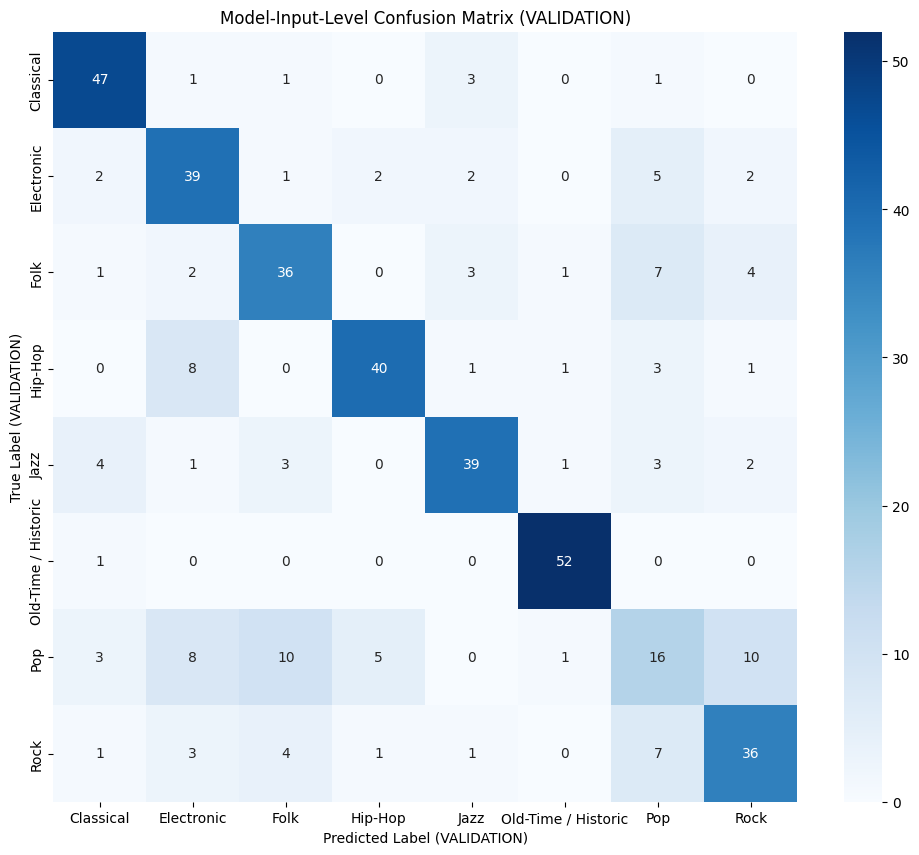


======== TRACK-LEVEL EVALUATION: VALIDATION | Majority Voting ========
Accuracy: 0.715962441314554
Balanced Accuracy: 0.7160202655485675
Macro F1: 0.7105942328383078

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.80      0.89      0.84        53
         Electronic       0.63      0.74      0.68        53
               Folk       0.65      0.67      0.66        54
            Hip-Hop       0.83      0.74      0.78        54
               Jazz       0.80      0.74      0.76        53
Old-Time / Historic       0.93      0.98      0.95        53
                Pop       0.38      0.30      0.34        53
               Rock       0.65      0.68      0.67        53

           accuracy                           0.72       426
          macro avg       0.71      0.72      0.71       426
       weighted avg       0.71      0.72      0.71       426

Saved majority-voting track predictions to: Results/PANN_normal_RandomFore

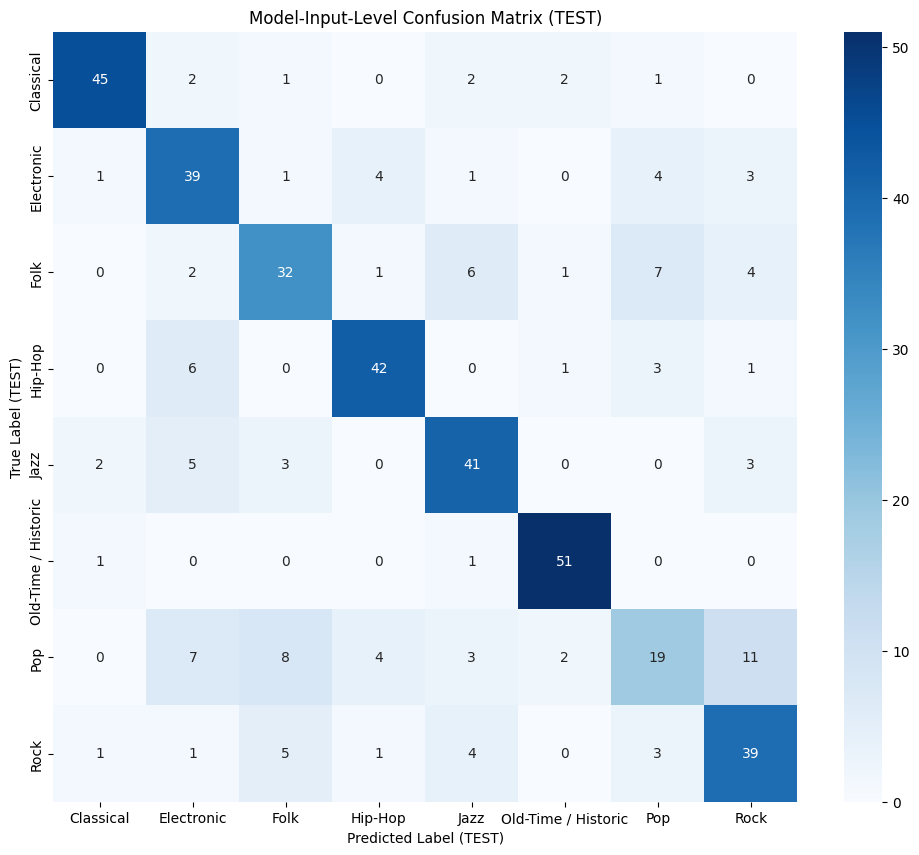


======== TRACK-LEVEL EVALUATION: TEST | Majority Voting ========
Accuracy: 0.7213114754098361
Balanced Accuracy: 0.7220911949685536
Macro F1: 0.7160831715245497

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.85      0.87        53
         Electronic       0.63      0.74      0.68        53
               Folk       0.64      0.60      0.62        53
            Hip-Hop       0.81      0.79      0.80        53
               Jazz       0.71      0.76      0.73        54
Old-Time / Historic       0.89      0.96      0.93        53
                Pop       0.51      0.35      0.42        54
               Rock       0.64      0.72      0.68        54

           accuracy                           0.72       427
          macro avg       0.72      0.72      0.72       427
       weighted avg       0.72      0.72      0.72       427

Saved majority-voting track predictions to: Results/PANN_normal_RandomForest_te

,track_id,segment_id,true_genre,predicted_genre
0,48811,0,Folk,Electronic
1,84107,0,Hip-Hop,Pop
2,33127,0,Electronic,Folk
3,127295,0,Pop,Rock
4,133789,0,Folk,Pop


: 

In [ ]:
# ---------------------------------------------------------
# TRAIN RANDOM FOREST ON PANN normal SEGMENT FEATURES
# ---------------------------------------------------------

MODEL_OUTPUT_NAME = "PANN_RandomForest"

param_distributions = {
    "n_estimators": [200, 300, 500, 800, 1000],
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="f1_macro",
    cv=5,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Starting Random Forest randomized search...")
random_search.fit(X_train, y_train)
print("Randomized search completed.")

clf = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV Macro F1:", random_search.best_score_)

rf_results = pd.DataFrame(random_search.cv_results_).sort_values("rank_test_score")
rf_results.to_csv(f"Results/{MODEL_OUTPUT_NAME}_random_search_results.csv", index=False)

joblib.dump(clf, f"Trained_Models/{MODEL_OUTPUT_NAME}.joblib")
joblib.dump(random_search, f"Trained_Models/{MODEL_OUTPUT_NAME}_randomsearch.joblib")
print(f"Saved model to Trained_Models/{MODEL_OUTPUT_NAME}.joblib")

# Validation evaluation on model-input level
y_val_pred = evaluate_model(clf, X_val, y_val, "VALIDATION", label_encoder)

# Validation evaluation on track level
track_level_val_results = evaluate_track_level(
    model=clf,
    X_data=X_val,
    y_true=y_val,
    track_ids=split_features["val"]["track_ids"],
    set_name="VALIDATION",
    label_encoder=label_encoder,
    output_name=MODEL_OUTPUT_NAME
)

# Final test evaluation on model-input level
y_test_pred = evaluate_model(clf, X_test, y_test, "TEST", label_encoder)

# Final test evaluation on track level
track_level_test_results = evaluate_track_level(
    model=clf,
    X_data=X_test,
    y_true=y_test,
    track_ids=track_ids_test,
    set_name="TEST",
    label_encoder=label_encoder,
    output_name=MODEL_OUTPUT_NAME
)

misclassified_samples = save_misclassified_samples(y_test_pred, MODEL_OUTPUT_NAME)
misclassified_samples.head()
